# CS412 Artificial Intelligence – Lab 6, Question 3
## Travelling Salesman Problem: Hill Climbing vs Simulated Annealing

This notebook:
1. Generates / loads TSP problem instances
2. Solves them with **Hill Climbing** (local search)
3. Solves them with **Simulated Annealing** (global optimisation)
4. Compares results graphically

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math, random, time, copy
from itertools import permutations

random.seed(42)
np.random.seed(42)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. TSP Problem Instances

We define three problem instances of increasing size:
- **Small** – 10 cities (random)
- **Medium** – 20 cities (random)
- **Large** – 50 cities (random)

You can replace these with real TSPLIB instances (see helper at the end of the notebook).

In [2]:
def generate_tsp_instance(n_cities, seed=None, name='TSP'):
    """Generate a random TSP instance with n_cities cities in [0,100]^2."""
    if seed is not None:
        np.random.seed(seed)
    coords = np.random.rand(n_cities, 2) * 100
    return {'name': name, 'coords': coords, 'n': n_cities}

problems = [
    generate_tsp_instance(10,  seed=1, name='Small  (10 cities)'),
    generate_tsp_instance(20,  seed=2, name='Medium (20 cities)'),
    generate_tsp_instance(50,  seed=3, name='Large  (50 cities)'),
]

for p in problems:
    print(f"{p['name']}  – first 3 coords: {p['coords'][:3].round(2)}")

Small  (10 cities)  – first 3 coords: [[4.170e+01 7.203e+01]
 [1.000e-02 3.023e+01]
 [1.468e+01 9.230e+00]]
Medium (20 cities)  – first 3 coords: [[43.6   2.59]
 [54.97 43.53]
 [42.04 33.03]]
Large  (50 cities)  – first 3 coords: [[55.08 70.81]
 [29.09 51.08]
 [89.29 89.63]]


## 3. Distance & Tour Utilities

In [3]:
def euclidean(c1, c2):
    return math.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

def build_distance_matrix(coords):
    n = len(coords)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i][j] = euclidean(coords[i], coords[j])
    return D

def tour_length(tour, D):
    """Total distance of a tour (cycle)."""
    total = sum(D[tour[i]][tour[i+1]] for i in range(len(tour)-1))
    total += D[tour[-1]][tour[0]]   # return to start
    return total

def random_tour(n):
    t = list(range(n))
    random.shuffle(t)
    return t

def two_opt_swap(tour, i, k):
    """Reverse the segment between positions i and k (2-opt move)."""
    return tour[:i] + tour[i:k+1][::-1] + tour[k+1:]

print('Utilities defined.')

Utilities defined.


## 4. Hill Climbing (Local Search)

**Algorithm:** Start with a random tour. Iteratively apply 2-opt swaps and accept a neighbour only if it is strictly better. Stop when no improvement is found (local optimum).

In [4]:
def hill_climbing(coords, D, max_restarts=5, verbose=False):
    """
    Hill Climbing with random restarts.
    Returns best tour, best distance, and history of distances per iteration.
    """
    n = len(coords)
    best_tour = None
    best_dist = float('inf')
    all_histories = []

    for restart in range(max_restarts):
        current_tour = random_tour(n)
        current_dist = tour_length(current_tour, D)
        history = [current_dist]
        improved = True

        while improved:
            improved = False
            for i in range(1, n - 1):
                for k in range(i + 1, n):
                    new_tour = two_opt_swap(current_tour, i, k)
                    new_dist = tour_length(new_tour, D)
                    if new_dist < current_dist:
                        current_tour = new_tour
                        current_dist = new_dist
                        history.append(current_dist)
                        improved = True
                        break
                if improved:
                    break

        all_histories.append(history)
        if current_dist < best_dist:
            best_dist = current_dist
            best_tour = current_tour

        if verbose:
            print(f'  Restart {restart+1}: final dist = {current_dist:.2f}')

    # Flatten history for plotting (concatenate restarts)
    flat_history = [d for h in all_histories for d in h]
    return best_tour, best_dist, flat_history

print('Hill Climbing defined.')

Hill Climbing defined.


## 5. Simulated Annealing (Global Optimisation)

**Algorithm:** Start with a random tour. At each step apply a random 2-opt swap:
- Accept if the new tour is better.
- Accept if worse with probability `exp(-Δ/T)` (allows escaping local optima).

The temperature `T` is cooled geometrically: `T ← T × α`.

In [5]:
def simulated_annealing(coords, D,
                        T_start=1000.0,
                        T_end=0.01,
                        alpha=0.995,
                        iterations_per_temp=100,
                        verbose=False):
    """
    Simulated Annealing for TSP.
    Returns best tour, best distance, and history of distances.
    """
    n = len(coords)
    current_tour = random_tour(n)
    current_dist = tour_length(current_tour, D)

    best_tour = current_tour[:]
    best_dist = current_dist

    T = T_start
    history = [current_dist]
    temp_history = [T]

    while T > T_end:
        for _ in range(iterations_per_temp):
            # Random 2-opt move
            i, k = sorted(random.sample(range(n), 2))
            new_tour = two_opt_swap(current_tour, i, k)
            new_dist = tour_length(new_tour, D)
            delta = new_dist - current_dist

            # Accept or reject
            if delta < 0 or random.random() < math.exp(-delta / T):
                current_tour = new_tour
                current_dist = new_dist

            if current_dist < best_dist:
                best_dist = current_dist
                best_tour = current_tour[:]

        history.append(current_dist)
        temp_history.append(T)
        T *= alpha

    if verbose:
        print(f'  SA finished: best dist = {best_dist:.2f}')

    return best_tour, best_dist, history, temp_history

print('Simulated Annealing defined.')

Simulated Annealing defined.


## 6. Run Both Algorithms on All Problems

In [6]:
results = []

for prob in problems:
    print(f"\n=== {prob['name']} ===")
    coords = prob['coords']
    D = build_distance_matrix(coords)

    # --- Hill Climbing ---
    t0 = time.time()
    hc_tour, hc_dist, hc_hist = hill_climbing(coords, D, max_restarts=5, verbose=True)
    hc_time = time.time() - t0
    print(f'  HC  best distance : {hc_dist:.2f}  (time: {hc_time:.3f}s)')

    # --- Simulated Annealing ---
    t0 = time.time()
    sa_tour, sa_dist, sa_hist, sa_temps = simulated_annealing(
        coords, D, T_start=1000, T_end=0.01, alpha=0.995,
        iterations_per_temp=200, verbose=True)
    sa_time = time.time() - t0
    print(f'  SA  best distance : {sa_dist:.2f}  (time: {sa_time:.3f}s)')

    results.append({
        'problem': prob,
        'D': D,
        'hc_tour': hc_tour, 'hc_dist': hc_dist,
        'hc_hist': hc_hist, 'hc_time': hc_time,
        'sa_tour': sa_tour, 'sa_dist': sa_dist,
        'sa_hist': sa_hist, 'sa_temps': sa_temps, 'sa_time': sa_time,
    })


=== Small  (10 cities) ===
  Restart 1: final dist = 189.93
  Restart 2: final dist = 189.93
  Restart 3: final dist = 189.93
  Restart 4: final dist = 189.93
  Restart 5: final dist = 189.93
  HC  best distance : 189.93  (time: 0.021s)
  SA finished: best dist = 189.93
  SA  best distance : 189.93  (time: 14.666s)

=== Medium (20 cities) ===
  Restart 1: final dist = 334.83
  Restart 2: final dist = 316.83
  Restart 3: final dist = 340.41
  Restart 4: final dist = 322.75
  Restart 5: final dist = 319.64
  HC  best distance : 316.83  (time: 0.315s)
  SA finished: best dist = 316.83
  SA  best distance : 316.83  (time: 21.286s)

=== Large  (50 cities) ===
  Restart 1: final dist = 575.69
  Restart 2: final dist = 597.41
  Restart 3: final dist = 557.96
  Restart 4: final dist = 586.85
  Restart 5: final dist = 593.36
  HC  best distance : 557.96  (time: 14.184s)
  SA finished: best dist = 551.62
  SA  best distance : 551.62  (time: 41.102s)


## 7. Graphical Comparison

### 7a. Best Tour Routes

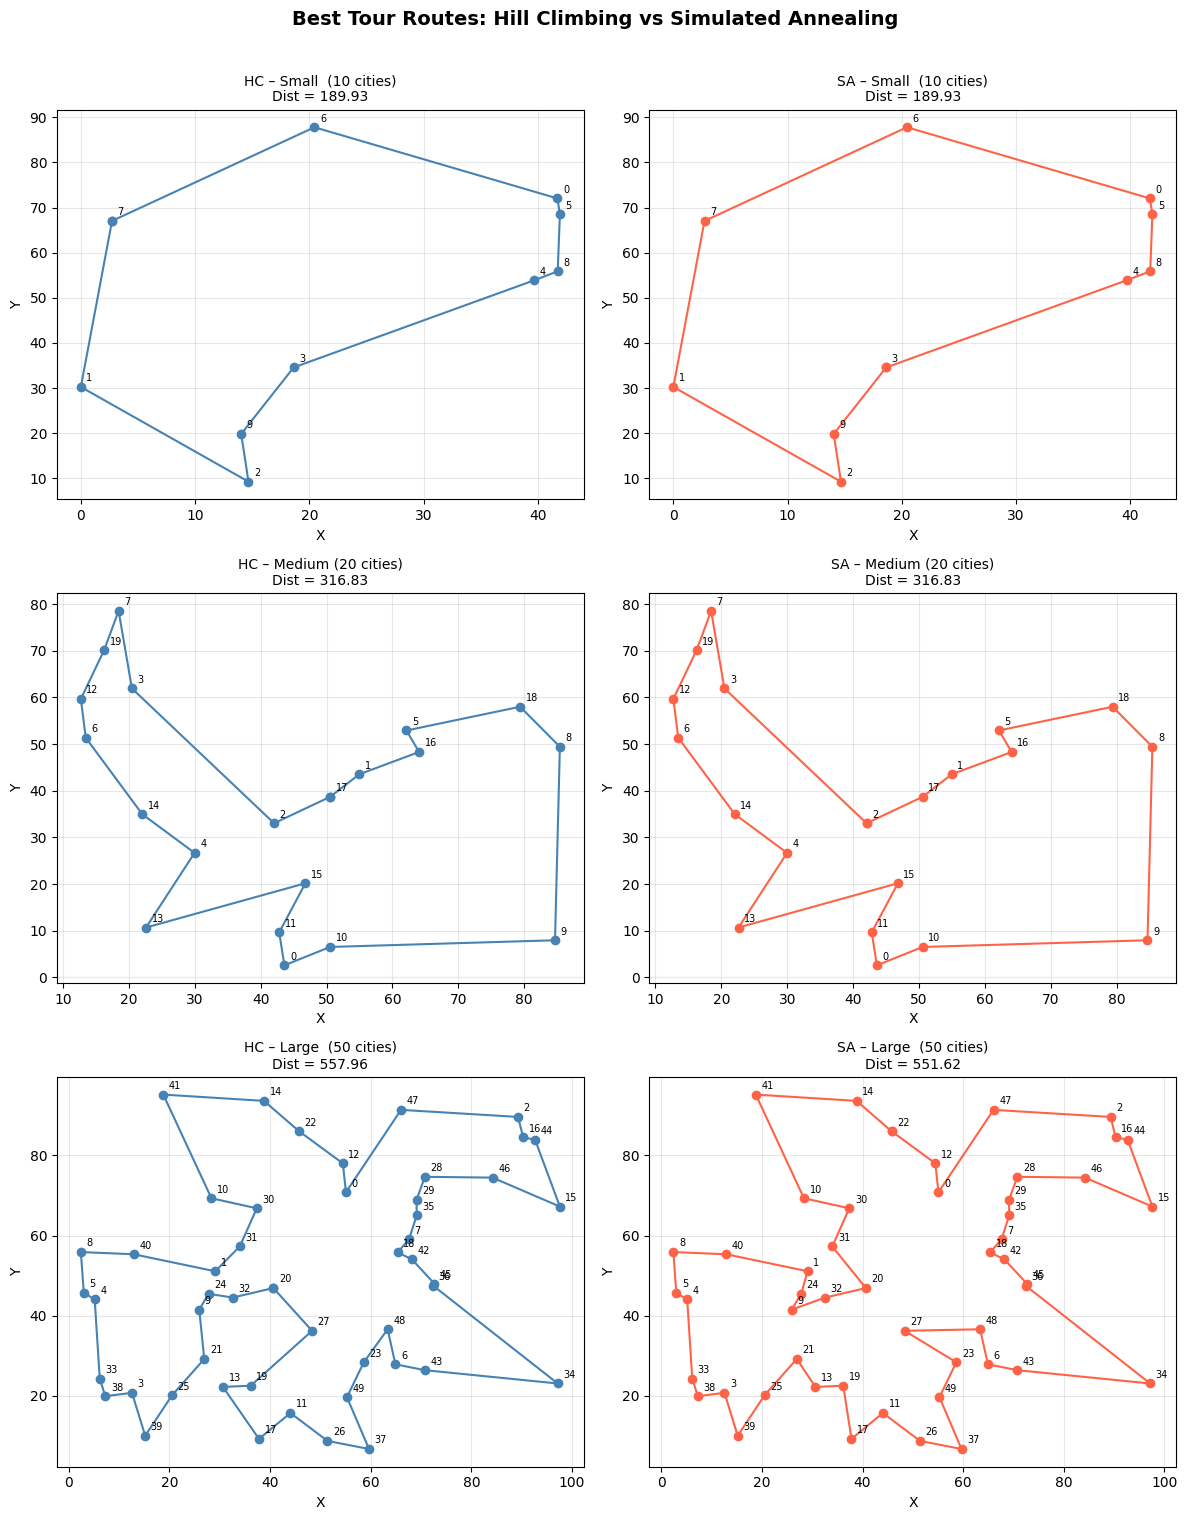

Tour routes saved to tour_routes.png


In [7]:
def plot_tour(ax, coords, tour, title, color):
    tour_coords = coords[tour + [tour[0]]]  # close the loop
    ax.plot(tour_coords[:, 0], tour_coords[:, 1],
            '-o', color=color, markersize=6, linewidth=1.5)
    for idx, (x, y) in enumerate(coords):
        ax.annotate(str(idx), (x, y), textcoords='offset points',
                    xytext=(4, 4), fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(len(results), 2, figsize=(12, 5 * len(results)))
fig.suptitle('Best Tour Routes: Hill Climbing vs Simulated Annealing',
             fontsize=14, fontweight='bold', y=1.01)

for row, r in enumerate(results):
    coords = r['problem']['coords']
    name   = r['problem']['name']

    plot_tour(axes[row, 0], coords, r['hc_tour'],
              f"HC – {name}\nDist = {r['hc_dist']:.2f}", 'steelblue')
    plot_tour(axes[row, 1], coords, r['sa_tour'],
              f"SA – {name}\nDist = {r['sa_dist']:.2f}", 'tomato')

plt.tight_layout()
plt.savefig('tour_routes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Tour routes saved to tour_routes.png')

### 7b. Convergence Curves (Distance over Iterations)

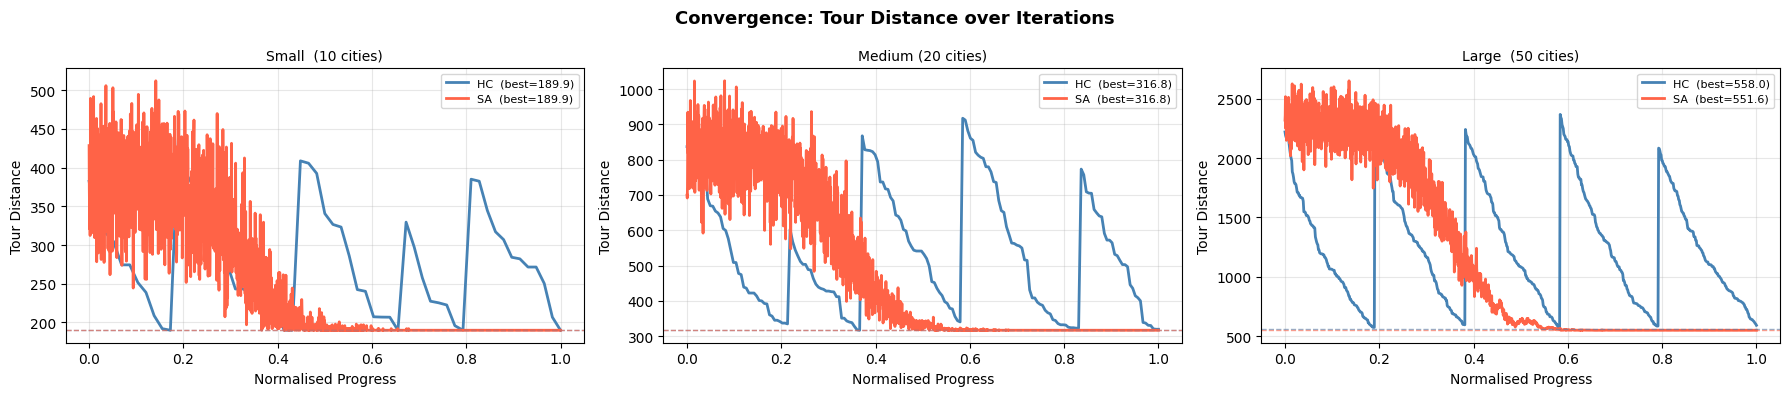

Convergence plot saved to convergence.png


In [8]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4))
fig.suptitle('Convergence: Tour Distance over Iterations',
             fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    name = r['problem']['name']

    # Normalise x-axis to [0,1] so both curves fit
    hc_x = np.linspace(0, 1, len(r['hc_hist']))
    sa_x = np.linspace(0, 1, len(r['sa_hist']))

    ax.plot(hc_x, r['hc_hist'], color='steelblue', linewidth=2, label=f"HC  (best={r['hc_dist']:.1f})")
    ax.plot(sa_x, r['sa_hist'], color='tomato',    linewidth=2, label=f"SA  (best={r['sa_dist']:.1f})")

    ax.axhline(r['hc_dist'], color='steelblue', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(r['sa_dist'], color='tomato',    linestyle='--', linewidth=1, alpha=0.6)

    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Normalised Progress')
    ax.set_ylabel('Tour Distance')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Convergence plot saved to convergence.png')

### 7c. Bar Chart – Best Distances Comparison

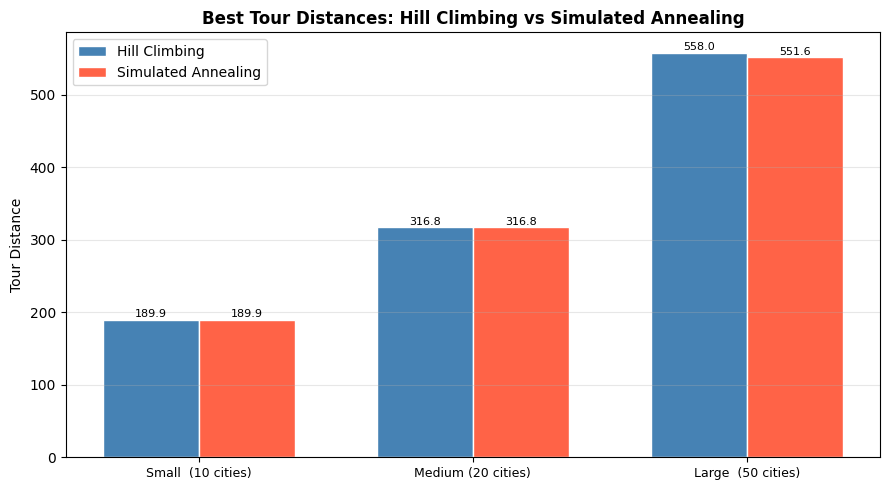

Distance comparison saved to distance_comparison.png


In [9]:
names     = [r['problem']['name'] for r in results]
hc_dists  = [r['hc_dist'] for r in results]
sa_dists  = [r['sa_dist'] for r in results]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, hc_dists, width, label='Hill Climbing', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, sa_dists, width, label='Simulated Annealing', color='tomato', edgecolor='white')

ax.set_title('Best Tour Distances: Hill Climbing vs Simulated Annealing',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Tour Distance')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('distance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Distance comparison saved to distance_comparison.png')

### 7d. SA Temperature Schedule

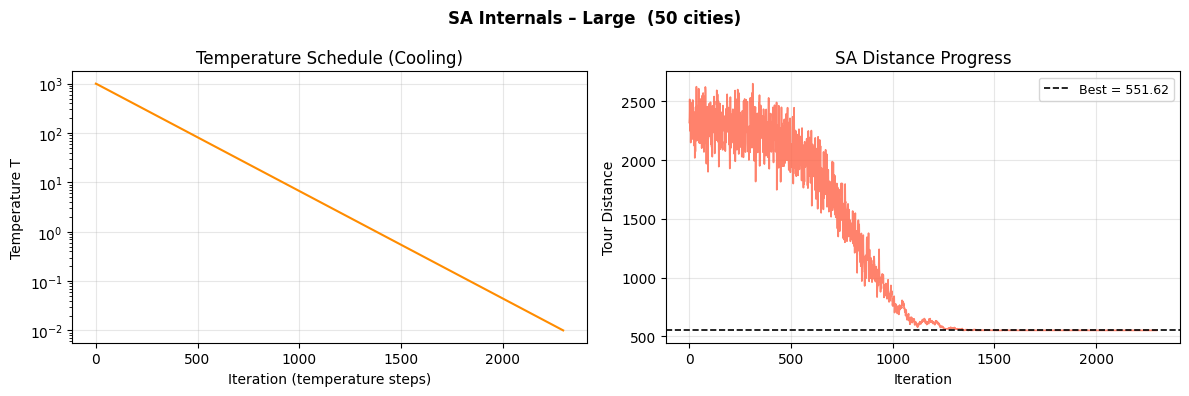

SA internals plot saved to sa_internals.png


In [10]:
# Show temperature decay for one problem (they are all the same schedule)
r = results[-1]  # largest problem

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"SA Internals – {r['problem']['name']}", fontsize=12, fontweight='bold')

ax1.plot(r['sa_temps'], color='darkorange', linewidth=1.5)
ax1.set_title('Temperature Schedule (Cooling)')
ax1.set_xlabel('Iteration (temperature steps)')
ax1.set_ylabel('Temperature T')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(r['sa_hist'], color='tomato', linewidth=1.2, alpha=0.8)
ax2.axhline(r['sa_dist'], color='black', linestyle='--', linewidth=1.2,
            label=f'Best = {r["sa_dist"]:.2f}')
ax2.set_title('SA Distance Progress')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Tour Distance')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sa_internals.png', dpi=120, bbox_inches='tight')
plt.show()
print('SA internals plot saved to sa_internals.png')

## 8. Summary Table

In [11]:
print(f"{'Problem':<22} {'HC Distance':>12} {'SA Distance':>12} {'Improvement %':>14} {'HC Time (s)':>12} {'SA Time (s)':>12}")
print('-' * 86)

for r in results:
    name  = r['problem']['name']
    hc_d  = r['hc_dist']
    sa_d  = r['sa_dist']
    improv = (hc_d - sa_d) / hc_d * 100
    print(f"{name:<22} {hc_d:>12.2f} {sa_d:>12.2f} {improv:>13.1f}% {r['hc_time']:>12.3f} {r['sa_time']:>12.3f}")

Problem                 HC Distance  SA Distance  Improvement %  HC Time (s)  SA Time (s)
--------------------------------------------------------------------------------------
Small  (10 cities)           189.93       189.93           0.0%        0.021       14.666
Medium (20 cities)           316.83       316.83           0.0%        0.315       21.286
Large  (50 cities)           557.96       551.62           1.1%       14.184       41.102


## 9. Discussion

| Aspect | Hill Climbing | Simulated Annealing |
|---|---|---|
| **Type** | Local search | Global optimisation |
| **Accepts worse moves?** | No | Yes (with probability $e^{-\Delta/T}$) |
| **Gets stuck in local optima?** | Yes | Less likely |
| **Speed** | Fast | Slower (more iterations) |
| **Solution quality** | Moderate | Generally better |
| **Tuning required** | Minimal | Yes ($T_0$, $\alpha$, schedule) |

**Key observation:** Simulated Annealing typically finds shorter tours than Hill Climbing, especially for larger instances, because it can escape local optima by occasionally accepting worse moves early in the search when the temperature is high. As the temperature cools, it becomes increasingly selective and converges to a high-quality solution.